# TP2 - Informe tecnico

Sistema de Deteccion y Clasificacion de Razas de Perros — IA 5.2 Computer Vision.

## Equipo
- Alumno 1 : Martinez Dufour, Caterina.
- Alumno 2 : Tapia, Fabrizio.

### Librerías

In [1]:
import pandas as pd
import numpy as np
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
from pathlib import Path
import random
import kagglehub
import shutil
import os
from torchvision import transforms as transforms
import cv2
import time

from insightface.model_zoo import get_model
import json
from tqdm import tqdm

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import gdown
import zipfile
import torch
import torchvision.models as models
from ultralytics import YOLO

## 1. Explicacion completa del pipeline

En esta sección se desarrolla el flujo continuo (End-to-End) del sistema, integrando todas las etapas desde la entrada de la imagen hasta la predicción final. El pipeline está diseñado de forma desacoplada y se compone de los siguientes módulos integrados:
- **Detección (YOLOv8n):** Recibe la imagen original cargada por el usuario en la interfaz. El modelo YOLOv8n procesa la escena, detecta la presencia del canino y genera una caja delimitadora (bounding box) para realizar un recorte (crop) preciso del perro, aislando el fondo.
- **Extracción de Embeddings (extract_embedding):** El recorte de la imagen se procesa mediante el modelo pre-entrenado ResNet-18 (sin la capa de clasificación final) para extraer su vector de características de dimensión 512.
- **Búsqueda por Similitud (search_similar_images):** El embedding generado se utiliza para consultar la base de datos vectorial (estructurada como una lista de registros en json_embeddings.json). A través de una métrica de distancia (Cosine Similarity o Distancia Euclidiana L2), se recuperan los 10 vectores más cercanos (Top-10).
- **Clasificación (predict_breed_from_neighbors):** Se predice la raza final del perro aplicando una votación por mayoría (k-NN) basada en las etiquetas de los 10 vecinos más cercanos recuperados, calculando además el score de confianza de la predicción.
- **Integración y Aplicación (Gradio):** Todos estos componentes se integran en la función principal pipeline_prediccion, la cual interactúa directamente con la interfaz de Gradio. La interfaz recibe como Input la imagen del perro, ejecuta el pipeline en el backend de forma transparente y devuelve como Output la raza predicha final junto con la visualización en cuadrícula del Top-10 de imágenes similares recuperadas. Los paths, parámetros y modelos se gestionan mediante variables de entorno (.env) para asegurar la portabilidad del sistema.

## 2. Dataset

In [2]:
# Descarga del dataset completo
dataset_path = kagglehub.dataset_download("gpiosenka/70-dog-breedsimage-data-set")
print(f"Los archivos se guardaron en la carpeta: {dataset_path}")

Los archivos se guardaron en la carpeta: C:\Users\Usuario\.cache\kagglehub\datasets\gpiosenka\70-dog-breedsimage-data-set\versions\2


Visualizamos algunas imágenes aleatorias para confirmar que la carga fue exitosa y verificar que los nombres de las carpetas correspondan a las identidades.

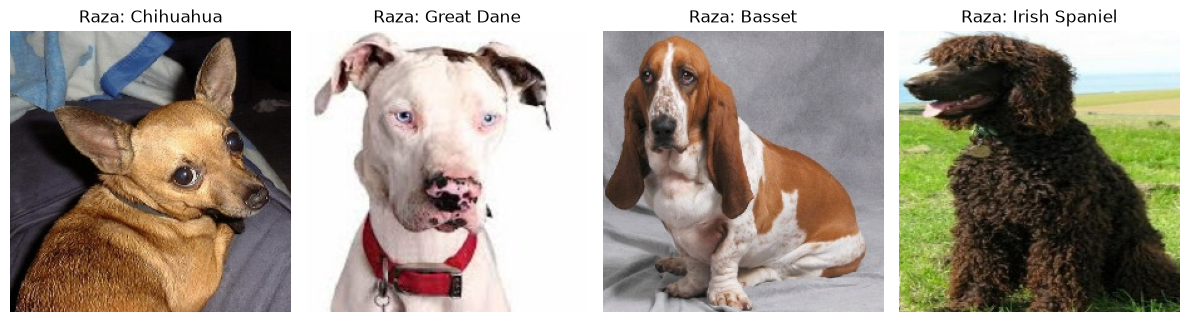

In [3]:
# Convertir la ruta de texto a objeto Path para poder usar .glob()
base_path = Path(dataset_path)
all_images = list(base_path.glob('**/*.jpg'))

# Visualizar las imágenes aleatorias
if all_images:
    sample_images = random.sample(all_images, min(4, len(all_images)))
    plt.figure(figsize=(12, 8))
    for i, img_path in enumerate(sample_images):
        plt.subplot(1, 4, i + 1)
        img = Image.open(img_path)
        plt.imshow(img)
        # parent.name extrae el nombre de la carpeta
        plt.title(f"Raza: {img_path.parent.name}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [4]:
# Contar imágenes por raza
identities = [p.parent.name for p in all_images]
counts = Counter(identities)
num_identities = len(counts)

print(f"\nAnálisis de razas:")
print(f"Total de razas únicas: {num_identities}")
print(f"Total de imágenes encontradas: {len(all_images)}")


Análisis de razas:
Total de razas únicas: 70
Total de imágenes encontradas: 9346


Podemos observar que hay una inconsistencia, observamos que hay un total de 71 razas y deberían ser 70 razas, por lo que analizaremos los nombres de cada raza para detectar si hay un error de carga:

In [5]:
print(sorted(list(counts.keys())))

['Afghan', 'African Wild Dog', 'Airedale', 'American Hairless', 'American Spaniel', 'Basenji', 'Basset', 'Beagle', 'Bearded Collie', 'Bermaise', 'Bichon Frise', 'Blenheim', 'Bloodhound', 'Bluetick', 'Border Collie', 'Borzoi', 'Boston Terrier', 'Boxer', 'Bull Mastiff', 'Bull Terrier', 'Bulldog', 'Cairn', 'Chihuahua', 'Chinese Crested', 'Chow', 'Clumber', 'Cockapoo', 'Cocker', 'Collie', 'Corgi', 'Coyote', 'Dalmation', 'Dhole', 'Dingo', 'Doberman', 'Elk Hound', 'French Bulldog', 'German Sheperd', 'Golden Retriever', 'Great Dane', 'Great Perenees', 'Greyhound', 'Groenendael', 'Irish Spaniel', 'Irish Wolfhound', 'Japanese Spaniel', 'Komondor', 'Labradoodle', 'Labrador', 'Lhasa', 'Malinois', 'Maltese', 'Mex Hairless', 'Newfoundland', 'Pekinese', 'Pit Bull', 'Pomeranian', 'Poodle', 'Pug', 'Rhodesian', 'Rottweiler', 'Saint Bernard', 'Schnauzer', 'Scotch Terrier', 'Shar_Pei', 'Shiba Inu', 'Shih-Tzu', 'Siberian Husky', 'Vizsla', 'Yorkie']


Podemos observar que la raza duplicada es 'American Spaniel', la cual fue escrita con un espacio de más. Para solucionar este problema, eliminaremos el espacio adicional unificando las carpetas en los 3 conjuntos dados (train, test y valid):

In [6]:
for split in ['train', 'test', 'valid']:
    split_dir = base_path / split
        
    # Definimos las rutas para ambas carpetas dentro del split actual
    carpeta_incorrecta = split_dir / "American  Spaniel"
    carpeta_correcta = split_dir / "American Spaniel"
    
    # Si la carpeta con el doble espacio existe, procedemos a unificarla
    if carpeta_incorrecta.exists():
        # Nos aseguramos de que la carpeta de destino correcta exista
        carpeta_correcta.mkdir(parents=True, exist_ok=True)
        # Movemos cada archivo .jpg a la ubicación corregida
        for archivo in carpeta_incorrecta.iterdir():
            shutil.move(str(archivo), str(carpeta_correcta / archivo.name))
            
        # Eliminamos la carpeta incorrecta
        carpeta_incorrecta.rmdir()

In [7]:
# Volvemos a escanear las imágenes para actualizar las rutas
all_images = list(base_path.glob('**/*.jpg'))

#### Análisis Estadístico de la distribución de las clases (global)

Para un sistema de reconocimiento de razas de perro, el balance del dataset es crítico. Analizaremos cuántas imágenes tenemos por perro y quiénes son las razas más frecuentes. Esto nos ayudará a decidir qué umbrales utilizar y cómo seleccionar nuestro conjunto de prueba.


Análisis de razas:
- Total de razas únicas: 70
- Promedio de fotos por raza: 134
- Raza con más fotos: Shih-Tzu (218 fotos)


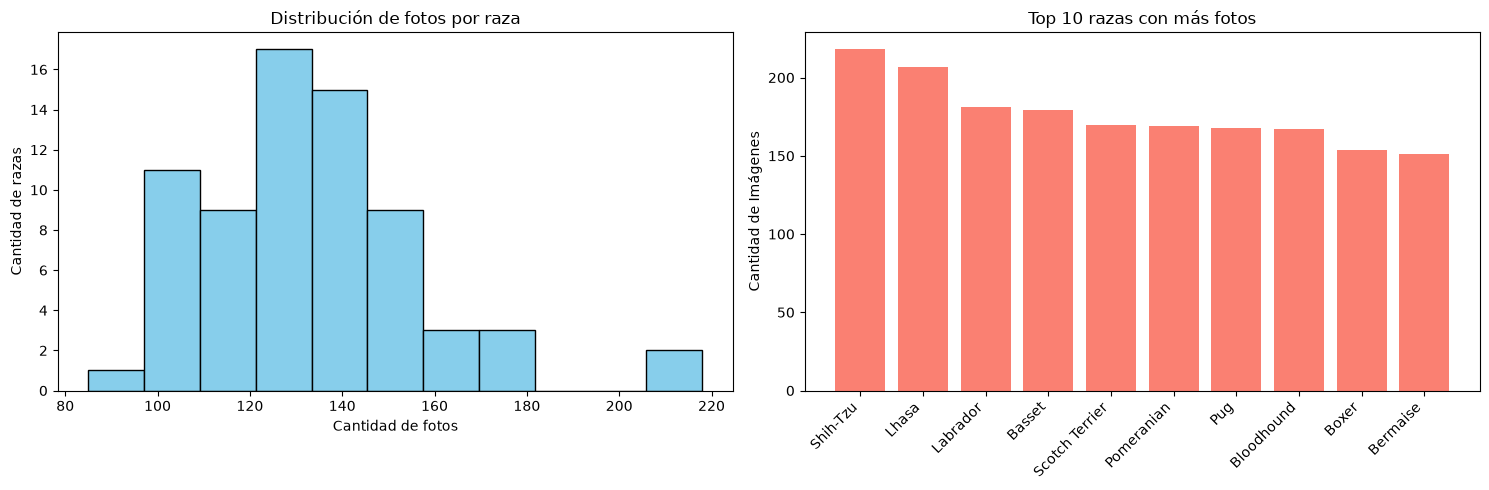

In [8]:
# Contar imágenes por raza (basado en el nombre de la carpeta padre)
identities = [p.parent.name for p in all_images]
counts = Counter(identities)

num_identities = len(counts)
img_per_breed = list(counts.values())

print(f"\nAnálisis de razas:")
print(f"- Total de razas únicas: {num_identities}")
print(f"- Promedio de fotos por raza: {len(all_images) / num_identities:.0f}")
print(f"- Raza con más fotos: {counts.most_common(1)[0][0]} ({counts.most_common(1)[0][1]} fotos)")

plt.figure(figsize=(15, 5))

# Visualización del histograma
plt.subplot(1, 2, 1)
plt.hist(img_per_breed, bins='auto', color='skyblue', edgecolor='black')
plt.title("Distribución de fotos por raza")
plt.xlabel("Cantidad de fotos")
plt.ylabel("Cantidad de razas")

# Visualización del Top 10
plt.subplot(1, 2, 2)
top_10 = counts.most_common(10)
plt.bar([x[0].replace('_', ' ') for x in top_10], [x[1] for x in top_10], color='salmon')
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 razas con más fotos")
plt.ylabel("Cantidad de Imágenes")

plt.tight_layout()
plt.show()

Visualizamos que la gran cantidad de razas tienen un promedio de 132 fotos, siendo la raza Shih-Tzu la que tiene más con 218 fotos. También observamos que hay un bloque sin datos entre las barras (una brecha visual). Para evitar que el modelo tenga un sesgo (bias) hacia las clases con más muestras, decidimos aplicar una estrategia de balanceo del dataset bajo los siguientes criterios:
- Umbral mínimo: Se fijó un requerimiento de un piso mínimo de 100 imágenes por raza para asegurar que el modelo tenga suficiente información para extraer características consistentes.
- Umbral máximo (Submuestreo): Se limitó a un máximo de 150 imágenes por raza para mantener un dataset equilibrado.

In [9]:
# Agrupamos todas las imágenes por raza
razas_dict = {}
for p in all_images:
    nombre = p.parent.name
    if nombre not in razas_dict:
        razas_dict[nombre] = []
    razas_dict[nombre].append(p)

MIN_IMG = 100
MAX_IMG = 150
all_images_filtradas = []
nombres_seleccionados = []

for nombre, fotos in razas_dict.items():
    if len(fotos) >= MIN_IMG:
        # Truncamos el exceso de fotos por encima del máximo
        seleccionadas = fotos[:MAX_IMG]
        all_images_filtradas.extend(seleccionadas)
        nombres_seleccionados.append(nombre)

print(f"Razas que cumplen el criterio ({MIN_IMG}-{MAX_IMG} fotos): {len(nombres_seleccionados)}")
print(f"Total de imágenes para procesar: {len(all_images_filtradas)}")

Razas que cumplen el criterio (100-150 fotos): 63
Total de imágenes para procesar: 8406


Como podemos observar en el resultado, las razas que superaban las 150 imágenes fueron recortadas, pero aquellas que se encuentran entre las 100 y 149 fotos conservan su cantidad original momentáneamente en esta estructura para la Etapa 1.

Por lo tanto, para que los tamaños no queden mezclados y garantizar un dataset perfectamente equilibrado y libre de sesgos, utilizaremos técnicas de Data Augmentation y remuestreo en la Etapa 2. De esta forma, expandiremos artificialmente las muestras de las clases minoritarias hasta que todas las razas presenten exactamente 150 imágenes.

#### Conjunto independiente para evaluación

Con el objetivo de evaluar la capacidad real de generalización de nuestro buscador por similitud (Etapa 1) y calcular la métrica NDCG@10, construimos un conjunto de evaluación independiente al dataset original de Kaggle. Para esto, recolectamos manualmente de internet un total de 140 imágenes (exactamente 2 imagenes por cada una de las 70 razas analizadas). El criterio de selección se basó en buscar imágenes que presenten desafíos visuales ausentes en el conjunto de entrenamiento, tales como variaciones en el fondo, diferentes ángulos de los perros y cambios de iluminación. 

Este dataset se estructuró en un directorio llamado conjunto_independiente_val, manteniendo las mismas etiquetas de las clases pero sin unificarlo físicamente con los splits originales. Para descargar el dataset lo realizamos a través del enlace de Google Drive: "https://drive.google.com/file/d/1yDWaOPtU1jUdSkLnkLqyVo9NetyhYZ1h/view". Descargamos desde el Drive el dataset de los perros en formato zip, lo descomprimimos y lo almacenamos:

In [10]:
# Definimos las rutas
base_path = Path(".")
dataset_original_path = Path(r"C:\Users\Usuario\.cache\kagglehub\datasets\gpiosenka\70-dog-breedsimage-data-set\versions\2")
eval_path = base_path / "data" / "conjunto_independiente_val"

# ID del archivo ZIP en Google Drive
file_id = '1yDWaOPtU1jUdSkLnkLqyVo9NetyhYZ1h'
url = f'https://drive.google.com/uc?id={file_id}'
archivo_descargado = base_path / "data" / 'dataset_perros.zip'

(base_path / "data").mkdir(parents=True, exist_ok=True)

# Descarga el archivo si no existe
if not eval_path.exists():
    gdown.download(url, str(archivo_descargado), quiet=False)
    # Extraemos el contenido
    try:
        print("Descomprimiendo archivos...")
        with zipfile.ZipFile(archivo_descargado, 'r') as zip_ref:
            zip_ref.extractall(base_path / "data")
            
        # Eliminar el archivo .zip temporal descargado
        if archivo_descargado.exists():
            os.remove(archivo_descargado)
        
    except zipfile.BadZipFile:
        print("Error")

## 3. Preprocesamiento

### Preprocesamiento de Datos (Etapa 1 - ResNet-18)

En este preprocesamiento estaremos realizando una redimensión de las imágenes a 224x224 píxeles, debido a que este es el tamaño de entrada estricto con el que fue diseñada y entrenada originalmente la arquitectura ResNet. Para poder pasar las nuevas imágenes por el modelo, primero las convertimos a un tensor, lo cual escala automáticamente los valores de los píxeles de un rango de 0-255 a un rango de 0 a 1. Finalmente, normalizamos utilizando la media y la desviación estándar oficiales de ImageNet, es por eso que pusimos esos valores específicos en el código, garantizando así que cualquier imagen externa se procese bajo la misma distribución estadística de iluminación y color con la que el modelo base fue pre-entrenado.

In [11]:
transform_etapa1 = transforms.Compose([
    transforms.ToPILImage(), # Agregamos esto solo para que acepte el array de OpenCV
    # Redimensionar la imagen en 224 x 224
    transforms.Resize((224, 224)),                         
    # Conversión a Tensor (convierte los píxeles de 0-255 a un rango de 0-1)
    transforms.ToTensor(),                                 
    # Normalización (media y desviación estándar)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

A diferencia del Resize y la Normalización, este filtro lo aplicamos de manera previa a la conversión de tensores mediante una rutina de validación con la librería PIL. Establecemos un umbral mínimo de resolución de 64x64 píxeles. Decidimos descartar aquellas imágenes que no cumplan con esta dimensión debido a que, al realizar el escalado forzado a 224x224, el proceso de interpolación genera un efecto de pixelado extremo (ruido geométrico). Esto distorsionaría las características visuales que extrae la ResNet18, degradando la precisión del buscador por similitud.

In [12]:
def calidad_img(path_imagen, min_dim):
    """
    Verifica si una imagen cumple con los estándares mínimos de calidad.
    """
    with Image.open(path_imagen) as img:
        ancho, alto = img.size
        if ancho < min_dim or alto < min_dim:
            return False # Descartada por resolución demasiado baja            
    return True # La imagen pasa el filtro de calidad

In [13]:
all_images_calidad = []

for p in all_images_filtradas:
    if calidad_img(p, min_dim=64):
        all_images_calidad.append(p)

imagenes_descartadas = len(all_images_filtradas) - len(all_images_calidad)
print(f"Total de imágenes descartadas por baja calidad: {imagenes_descartadas}")

Total de imágenes descartadas por baja calidad: 0


### Procesamiento de Datos y Estrategia de Regularización (Etapa 2 - ResNet-18 Fine-Tuned)

Para el ajuste fino (*fine-tuning*) de la red **ResNet-18**, el preprocesamiento y la aumentación de datos se diseñaron críticamente para balancear la generalización del modelo, evitando tanto el sobreajuste (*overfitting*) como el subajuste (*underfitting*), dada la complejidad de clasificar 70 razas de perros.

#### 1. Transformación de Base y Validación (`transform_etapa2`)
Aplicada al conjunto de validación y como control geométrico estable. Su función es adaptar las imágenes del dataset crudo al formato estandarizado que exige la arquitectura ResNet-18 preentrenada en ImageNet:

* **Resize ((224, 224)):** Redimensiona directamente las imágenes a la resolución nativa de entrada de la ResNet-18, asegurando la consistencia dimensional de los tensores.
* **ToTensor():** Convierte las imágenes a tensores de PyTorch, reescalando los valores de los píxeles del rango entero $[0, 255]$ al rango de punto flotante $[0.0, 1.0]$.
* **Normalize:** Aplica la normalización estadística utilizando la media ($\mu$) y desviación estándar ($\sigma$) oficiales de ImageNet. Esto es mandatorio para que las distribuciones de los datos de entrada coincidan con la escala de los pesos preentrenados del modelo:
  $$\mu = [0.485, 0.456, 0.406], \quad \sigma = [0.229, 0.224, 0.225]$$

#### 2. Pipeline de Aumentación Optimizado (`transform_aug`)
Para el conjunto de entrenamiento, se diseñó un pipeline de aumentación estocástica con el objetivo de generar variabilidad artificial. Sin embargo, tras experimentar con el comportamiento de la pérdida, **se optó por una estrategia de aumentación moderada** para mitigar el riesgo de *underfitting*:

* **RandomHorizontalFlip(p=0.5):** Espejado horizontal aleatorio. Dota al modelo de invariancia posicional, permitiéndole reconocer a la raza sin importar si el canino mira hacia la izquierda o la derecha.
* **RandomRotation(degrees=15):** Rotación aleatoria limitada a un máximo de 15 grados (reducida desde un valor inicial de 30°). Esta decisión se tomó porque rotaciones excesivas deformaban severamente la silueta del perro, perjudicando la extracción de características morfológicas clave.
* **GaussianBlur(kernel_size=5):** Desenfoque gaussiano suave para otorgar robustez frente a imágenes que sufran de baja resolución o sutiles movimientos de cámara.
* **ColorJitter(brightness=0.2, contrast=0.2):** Modificación controlada de brillo y contraste (atenuada desde un valor inicial agresivo de 0.5). Permite al modelo independizarse de las condiciones lumínicas del entorno de captura (interior, exterior, sombras) sin alterar drásticamente la paleta cromática real del pelaje.
* **Remoción del Ruido Gaussiano Aditivo (`transforms.Lambda`):** Durante la fase de calibración, se eliminó la inyección de ruido aleatorio mediante funciones Lambda (`torch.randn_like`). Se justificó su remoción al detectar que penalizaba excesivamente la capacidad de representación de la red, actuando como un regulador demasiado agresivo para el volumen de nuestro dataset y empujando al modelo hacia una situación de *underfitting*.

## 4. Justificacion de los modelos elegidos

### Modelo de embeddings baseline (Etapa 1)

En esta sección se desarrolla la función principal de predicción, integrando todas las etapas del sistema en un flujo continuo (End-to-End). La función recibe una imagen sin procesar y ejecuta el pipeline completo:

- extract_embedding(image): Código para pasar una imagen por el modelo pre-entrenado en ImageNet (ResNet18) y extraer su vector de características.  
- search_similar_images(embedding, top_k=10): Código para buscar los 10 vectores más cercanos (Top-10) en la base de datos vectorial (usando JSON) mediante Cosine Similarity o Distancia Euclidiana (L2).  
- predict_breed_from_neighbors(results): Código para predecir la raza del perro basándote en las etiquetas de las imágenes más similares encontradas (los vecinos más cercanos).

Especificaciones de la Interfaz (Gradio):
- Input: Imagen de un perro.
- Output: Imagen consultada, visualización en cuadrícula del Top 10 de imágenes similares recuperadas de la base de datos, y la Raza predicha final.

In [14]:
def load_image(source_path: str) -> np.ndarray:
    image = cv2.imread(str(source_path))
    if image is None:
        raise ValueError(f"Could not read image: {source_path}") # BGR uint8 (convencion OpenCV)
    return image

#### Extraer embeddings de imágenes

Para extraer los embeddings decidimos utilizar el modelo pre-entrenado de ResNet-18, debido a que devuelve un vector de 512 dimensiones por cada imagen. A diferencia de EfficientNet-B0 (que genera 1280 dimensiones) o ResNet-50 (con 2048), esto nos da un espacio geométrico más amplio para almacenar detalles morfológicos y estructuras globales de los perros. Además, presenta un consumo de memoria bajo y una velocidad de inferencia sumamente rápida en entornos de GPU.

In [ ]:
def extract_embedding(image: np.ndarray) -> list[float]:
    """
    Genera el embedding de una imagen usando un modelo pre-entrenado en
    ImageNet (ResNet18) sin la capa de clasificacion final.

    Sugerencias:
        - Preprocesar la imagen (resize a self.image_size, normalizacion ImageNet).
        - Usar torchvision.models o timm con pesos pre-entrenados.
        - Recordar que la imagen llega en BGR (OpenCV).
    Retorna una lista de floats de dimension EMBEDDING_DIM.
    """
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)                # Convertimos de BGR a RGB 
    tensor_image = transform_etapa1(image_rgb)                        # Aplicamos las transformaciones
    tensor_image = tensor_image.unsqueeze(0)                          # agrega una dimensión extra de tamaño 1 en la posición 0
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)  # Cargamos el modelo ResNet-18
    model.fc = torch.nn.Identity()                                    # Reemplazamos la última capa lineal de clasificación (.fc) por Identity
    
    model.eval()

    # Extracción de la lista de Floats
    with torch.no_grad():
        output = model(tensor_image)                                  # Pasamos el tensor por la red neuronal
        embedding_np = output.squeeze().cpu().numpy()                 # Del tensor se elimina las dimensiones extra de tamaño 1 y lo convierte a un array
        embedding_list = embedding_np.tolist()                        # Convertimos el array a una lista de Python

    return embedding_list

####  Construir una base de datos vectorial

A continuación, construimos una base de datos vectorial local en formato JSON para almacenar los embeddings indexados. La información se organiza en una estructura de diccionario donde cada clave (ruta de la imagen) contiene los atributos breed (raza) y embedding (vector de características). Este archivo servirá como nuestro Feature Store para utilizar de forma eficiente la función search_similar_images.

In [16]:
ARCHIVO_JSON = "json_embeddings.json"
galeria_lista = []

# Usamos enumerate() para tener un índice numérico que sirva de ID
for idx, path in enumerate(tqdm(all_images_calidad, desc="Indexando")):
    try:
        path_str = str(path)                                   # Convertimos el path a un string plano de Python
        breed = os.path.basename(os.path.dirname(path_str))    # Extraemos la raza de la carpeta
        img = load_image(path_str)                             # Cargamos la imagen
        emb = extract_embedding(img)                           # extraemos sus características
        
        # Guardamos la estructura
        registro = {
            "id_imagen": str(idx),                     
            "embedding": emb,                               
            "path": path_str,                               
            "breed": breed,                                 
            "metadata": {}                                  
        }
        
        galeria_lista.append(registro)

    except Exception as e:
        continue

# Guardamos la lista
with open(ARCHIVO_JSON, 'w') as f:
    json.dump(galeria_lista, f, indent=4)

Indexando: 100%|██████████| 8406/8406 [1:06:35<00:00,  2.10it/s]


#### Recuperar imágenes similares (search_similar_images)

Para implementar la recuperación de imágenes similares, utilizamos el archivo json_embeddings generado previamente en conjunto con las funciones provistas por la cátedra: cosine (similitud del coseno), l2_similarity (distancia euclidiana normalizada) y similarity (función unificada que actúa como selector de métrica). La evaluación cuantitativa para determinar cuál de las dos métricas ofrece un mejor rendimiento en el modelo final se detallará en la sección "6. Resultados obtenidos, Etapa 1: NDCG@10 y justificación del resultado".

In [17]:
def cosine(a: np.ndarray, b: np.ndarray) -> float:
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)

def l2_similarity(a: np.ndarray, b: np.ndarray) -> float:
    dist = float(np.linalg.norm(a - b))
    return 1.0 / (1.0 + dist)

def similarity(query: list[float], ref: list[float], similarity_metric: str = "cosine") -> float:
    a = np.asarray(query, dtype=np.float32)
    b = np.asarray(ref, dtype=np.float32)
    if similarity_metric.lower() == "l2":
        return l2_similarity(a, b)
    return cosine(a, b)

Esta función se encarga de recuperar desde nuestro almacenamiento local en JSON el Top - K de las imágenes más similares al embedding de consulta. El algoritmo itera sobre todos los elementos indexados, calcula el score de similitud delegando la operación en la función similarity (aplicando Coseno o L2 de manera dinámica según el parámetro seleccionado) y finalmente ordena el conjunto de forma descendente para retornar los K vecinos más cercanos.

In [18]:
def search_similar_images(embedding: list[float], top_k: int, metric: str) -> list[dict]:
    """
    Recupera de la base vectorial las top_k imagenes mas similares.
    Busca de forma local en el archivo JSON e itera los elementos usando similarity().
    """
    with open("json_embeddings.json", "r") as f:                    # Lee el archivo JSON
        db = json.load(f)
        
    raw_results = []

    for registro in db:                                             # Recorremos el diccionario del JSON
        path = registro["path"]
        breed = registro["breed"]
        stored_embedding = registro["embedding"]
        
        # Usamos la función con la metrica elegida (coseno o L2)
        score = similarity(embedding, stored_embedding, similarity_metric=metric)
        
        # Guardamos en un diccionario nativo
        raw_results.append({
            "path": path,
            "breed": breed,
            "score": score
        })
        
    # Gracias a la normalización L2 (1 / 1 + dist), ambas métricas a mayor valor, tienen mayor similitud
    # Ordenamos de forma descendente para asegurar que el Top-K contenga los mejores resultados
    raw_results.sort(key=lambda x: x["score"], reverse=True)
    
    return raw_results[:top_k]

#### Clasificar razas utilizando búsqueda por similitud

Para resolver la predicción final de la raza a partir de los K resultados recuperados del JSON, implementamos una variante del algoritmo k-NN con voto ponderado por similitud. El flujo de clasificación consta de:
-  Umbral de Similitud: Dado que el ranking de vecinos se encuentra ordenado de forma decreciente, evaluamos el primer elemento (el más similar). Si este score es inferior a un umbral crítico de 0.5, el sistema determina que la imagen como "unknown" (desconocido). 
-  Votación Ponderada: Utilizamos el score de similitud de cada vecino como el peso de su voto. De este modo, los perros recuperados del JSON con un nivel de confianza muy alto tienen un impacto significativamente mayor en la decisión final.

Tras iterar los resultados y acumular los pesos en un diccionario de frecuencias, se extrae la raza que haya recolectado el mayor puntaje consolidado. Finalmente, la función retorna una tupla compuesta por la raza ganadora y el score de confianza individual del mejor vecino.

In [19]:
def predict_breed_from_neighbors(results: list[dict]) -> tuple[str, float]:
    """
    Predice la raza a partir de los vecinos recuperados usando k-NN ponderado por score.
    Si el mejor score del primer vecino es menor a similarity_threshold, devuelve "unknown".
    """
    # Si la búsqueda no trajo nada, se clasifica como 'desconocido'
    if not results:
        return "unknown", 0.0
        
    # Como la lista ya viene ordenada de mayor a menor, el primer elemento es el que tiene el score más alto.
    mejor_score = results[0]["score"]
    if mejor_score < 0.5:
        return "unknown", 0.0

    # Aplica k-NN con Voto Ponderado
    votos_por_raza = {}
    
    for vecino in results:
        raza = vecino["breed"]
        score = vecino["score"]
        
        # Sumamos el score como el "peso" del voto para esa raza
        if raza in votos_por_raza:
            votos_por_raza[raza] += score
        else:
            votos_por_raza[raza] = score
            
    # Obtiene la raza más votada
    raza_ganadora = max(votos_por_raza, key=votos_por_raza.get)
    
    return raza_ganadora, mejor_score

#### Pipeline completo

In [20]:
def pipeline_prediccion(image, top, metrica) -> tuple[str, float, list[dict]]:
    """
    Pipeline principal End-to-End. Integra Carga, Extracción, Búsqueda y Clasificación k-NN.
    
    Input: Imagen de un perro.
    Output: Imagen consultada del Top k de imágenes similares recuperadas de la base de datos, y la Raza predicha final.
    """
    # Carga la imagen
    if isinstance(image, str):
        img = load_image(image)
    else:
        img = image 
        
    # Extracción de embedding
    embedding = extract_embedding(img)
    
    # Búsqueda de imágenes similares
    vecinos = search_similar_images(embedding, top_k=top, metric=metrica)
    
    # Clasificación de raza 
    raza_final, confianza = predict_breed_from_neighbors(vecinos)
    
    return raza_final, confianza, vecinos

### ResNet18 fine-tuned y CNN custom (Etapa 2)



#### 1. Eleccion: ResNet-18
* **Baja latencia:** Con ~11 millones de parámetros, es lo suficientemente ligera para procesar los recortes (*crops*) en milisegundos. Es ideal para un *pipeline Two-Stage* que necesita operar rápido en entornos de producción o contenedores sin requerir hardware de GPU avanzado.
* **Eficiencia arquitectónica:** Sus conexiones residuales (*skip connections*) garantizan un aprendizaje profundo y robusto, logrando un balance óptimo entre velocidad y precisión sin la sobrecarga computacional de modelos más pesados (como ResNet-50).

#### 2. ¿Por qué un Fine-Tuning completo?
* **Clasificación de grano fino:** Diferenciar 70 razas de perros exige un análisis visual muy detallado. Descongelar todas las capas permite que la red ajuste sus filtros iniciales para especializarse en texturas de pelaje y morfologías caninas específicas.
* **Adaptación al dominio:** El modelo base fue entrenado con ImageNet (imágenes generales). Al reentrenar toda la red, adaptamos los pesos a la nueva distribución de imágenes que entrega YOLO: recortes ajustados exclusivamente al cuerpo del animal, sin contexto de fondo.

#### Diseño de CNN Propia

El diseño de la arquitectura `CNNPropia` se construyó desde cero priorizando la eficiencia computacional y la mitigación del sobreajuste (*overfitting*), incorporando técnicas modernas de *Deep Learning*:

* **Extracción Progresiva (4 Bloques Convolucionales):** La red aumenta su capacidad de representación de forma escalonada (32 → 64 → 128 → 256 filtros). Esto le otorga la profundidad necesaria para capturar desde patrones básicos hasta características complejas requeridas para clasificar 70 razas distintas, manteniendo un peso ligero.
* **Skip Connection (Conexión Residual):** Se implementó un atajo en el Bloque 2, utilizando una convolución de 1x1 (`shortcut_b2`) para emparejar las dimensiones. Esto facilita el flujo de información e impide el desvanecimiento del gradiente, mejorando la convergencia durante el entrenamiento.
* **Global Average Pooling (GAP):** El uso de `AdaptiveAvgPool2d` antes de la capa lineal reduce drásticamente la cantidad de parámetros entrenables en comparación con un aplanado tradicional (*flatten*). Esto optimiza el uso de memoria y actúa como un excelente regularizador estructural.
* **Estabilidad y Regularización Activa:** La aplicación sistemática de `BatchNorm2d` en todos los bloques estabiliza las activaciones internas. Combinado con un `Dropout` fuerte del 40% (0.4) en la etapa final, se fuerza a la red a generalizar características robustas, evitando que memorice el set de entrenamiento.

### YOLO (Etapa 3)

Análisis de Trade-Offs del Pipeline (Detección y Clasificación)
El diseño de esta arquitectura (YOLOv8 + ResNet-18) implicó tomar decisiones estratégicas para balancear el rendimiento general del sistema. A continuación, se analizan los compromisos (trade-offs) asumidos:

1. Velocidad de Inferencia vs. Precisión (El uso de YOLOv8n)

Decisión: Se optó por la versión Nano (YOLOv8n) como detector principal.

Trade-off: Se priorizó una velocidad de inferencia altísima y un consumo de memoria mínimo, ideal para correr en entornos locales o contenedores Docker sin GPU. El costo a pagar (trade-off) es una ligera pérdida de precisión en escenas muy complejas o con oclusiones severas. Por ejemplo, en pruebas con múltiples perros superpuestos, el modelo liviano puede presentar confusiones inter-clase, requiriendo un umbral de confianza estricto para no arrastrar errores al clasificador.

2. Complejidad Computacional vs. Especialización 

Decisión: Separar el problema en dos modelos distintos en lugar de entrenar un único YOLO para detectar y clasificar las 70 razas simultáneamente.

Trade-off: Aumenta la complejidad computacional y el consumo de memoria general, ya que el sistema debe cargar y orquestar dos redes neuronales distintas en memoria. A cambio, se maximiza radicalmente la precisión de clasificación de grano fino, ya que ResNet-18 evalúa un recorte limpio y estandarizado, libre del "ruido" del fondo que procesó YOLO.

3. Precisión de Detección vs. Tasa de Falsos Positivos (Umbral de Confianza)

Decisión: Establecer el umbral de detección (conf_threshold) de YOLO en 0.5 (50%).

Trade-off: Se prioriza la seguridad de que el recorte enviado al clasificador contenga efectivamente un perro, minimizando los falsos positivos (como detectar una sombra o un mueble). El costo es una reducción en la sensibilidad (tasa de recall), pudiendo ignorar perros legítimos si se encuentran muy lejos, borrosos o en condiciones de baja iluminación.

#### Detección de razas

In [6]:
# Cargar el modelo YOLO preentrenado (YOLOv8)
model = YOLO('yolov8n.pt')
conf_threshold = 0.5

def detect_dogs(image: np.ndarray) -> list[tuple[tuple[int, int, int, int], float]]:
    """
    Detecta todos los perros presentes en la imagen usando un modelo YOLO
    pre-entrenado (ej: YOLOv8n via ultralytics). No es necesario entrenar el detector.

    Sugerencias:
    - self.yolo_model_name, self.conf_threshold y self.dog_class_id(clase 'dog' = 16 en COCO) vienen de la configuracion (.env).
    - Debe funcionar con un perro, multiples perros y escenas complejas.

    Retorna una lista de ((x1, y1, x2, y2), confidence) en pixeles.
    """
    results = model(image, conf=conf_threshold, verbose=False)
    
    detecciones_perros = []
    
    if results and len(results) > 0:
        for box in results[0].boxes:
            class_id = int(box.cls[0].item())
            
            if class_id == 16: # Clase 'dog' en COCO
                coords = box.xyxy[0].tolist()
                
                x1 = int(round(coords[0]))
                y1 = int(round(coords[1]))
                x2 = int(round(coords[2]))
                y2 = int(round(coords[3]))
                
                confidence = float(box.conf[0].item())
                detecciones_perros.append(((x1, y1, x2, y2), confidence))
                
    return detecciones_perros

Detecciones encontradas: [((8, 17, 250, 316), 0.6682116985321045)]


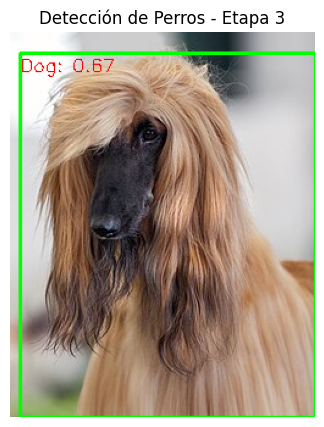

In [15]:
ruta_img = r"data\conjunto_independiente_val\afghan\afghan_1.jpg"
img_prueba = cv2.imread(ruta_img)
resultados = detect_dogs(img_prueba)
print("Detecciones encontradas:", resultados)
#recorte del bounding boxes + score

img_visualizacion = img_prueba.copy()

for i, (bbox, score) in enumerate(resultados):
    x1, y1, x2, y2 = bbox

    cv2.rectangle(img_visualizacion, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img_visualizacion, text=f"Dog: {score:.2f}", org=(x1, y1 + 15),  fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.5, color=(0, 0, 255), thickness=1)

img_rgb = cv2.cvtColor(img_visualizacion, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(9, 5))
plt.imshow(img_rgb)
plt.axis('off')  # Oculta los ejes de coordenadas
plt.title("Detección de Perros - Etapa 3")
plt.show()

#### Clasificación de la raza recortada

In [8]:
def classify_detected_dog(crop: np.ndarray) -> tuple[str, float]:
    """
    Clasifica la raza del recorte de un perro detectado usando el modelo entrenado en la Etapa 2 (self.classifier.load_model()).
    El recorte llega en BGR (OpenCV). Retorna (raza, score).
    """
        # Convertir BGR (OpenCV) a RGB y luego a formato imagen (PIL)
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(crop_rgb)

    # Aplicar las mismas transformaciones estrictas de validación/test
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Añadimos la dimensión de batch que PyTorch necesita: [1, 3, 224, 224]
    input_tensor = transform(pil_img).unsqueeze(0) 

    
    model = self.classifier.load_model()
    device = next(model.parameters()).device 
    input_tensor = input_tensor.to(device)
    
    model.eval()

    #  Pasar por la red neuronal
    with torch.no_grad():
        output = model(input_tensor)
        # Pasamos la salida lineal por una función softmax para obtener porcentajes reales (0 a 1)
        probs = F.softmax(output, dim=1)
        score_tensor, pred_tensor = torch.max(probs, dim=1)
        
    score = float(score_tensor.item())
    pred_id = int(pred_tensor.item())

    # Leemos directamente las carpetas de entrenamiento y las ordenamos alfabéticamente
    import os
    ruta_dataset = "data/dataset/train" 
    
    try:
        nombres_de_clases = sorted([d for d in os.listdir(ruta_dataset) if os.path.isdir(os.path.join(ruta_dataset, d))])
        breed = nombres_de_clases[pred_id]
    except FileNotFoundError:
        breed = f"raza_id_{pred_id}"
        
    return breed, score



 Iniciando Pipeline por Lotes: Detección (YOLOv8n) + Clasificación (ResNet18)...

------------------------------------------------------------
 Analizando imagen: 3perros.jpg
------------------------------------------------------------


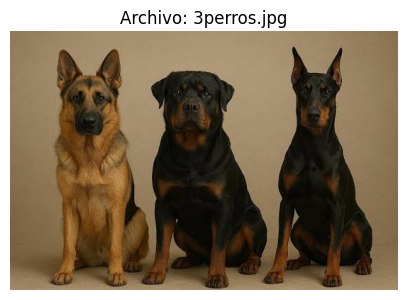

DEBUG YOLO: Encontró 3 objetos en total.
DEBUG FILTRO: La lista final que devuelve la función tiene 3 perro(s).

=== RESULTADO DE LA PREDICCIÓN ===
{
    "type": "detect",
    "source_path": "data\\validacion_etapa3\\3perros.jpg",
    "detections": [
        {
            "bbox": [
                358,
                18,
                513,
                360
            ],
            "det_score": 0.9533,
            "breed": "Doberman",
            "breed_score": 0.9994
        },
        {
            "bbox": [
                190,
                54,
                364,
                361
            ],
            "det_score": 0.9243,
            "breed": "Rottweiler",
            "breed_score": 0.9897
        },
        {
            "bbox": [
                59,
                23,
                192,
                360
            ],
            "det_score": 0.8862,
            "breed": "German Sheperd",
            "breed_score": 0.8308
        }
    ],
    "detected_br

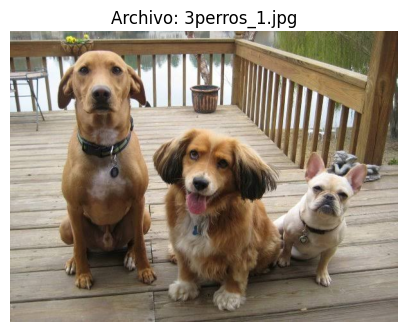

DEBUG YOLO: Encontró 3 objetos en total.
DEBUG FILTRO: La lista final que devuelve la función tiene 3 perro(s).

=== RESULTADO DE LA PREDICCIÓN ===
{
    "type": "detect",
    "source_path": "data\\validacion_etapa3\\3perros_1.jpg",
    "detections": [
        {
            "bbox": [
                73,
                29,
                228,
                402
            ],
            "det_score": 0.9307,
            "breed": "Rhodesian",
            "breed_score": 0.6951
        },
        {
            "bbox": [
                221,
                150,
                425,
                435
            ],
            "det_score": 0.8869,
            "breed": "Golden Retriever",
            "breed_score": 0.9862
        },
        {
            "bbox": [
                411,
                185,
                557,
                400
            ],
            "det_score": 0.8789,
            "breed": "French Bulldog",
            "breed_score": 0.9125
        }
    ],
    "

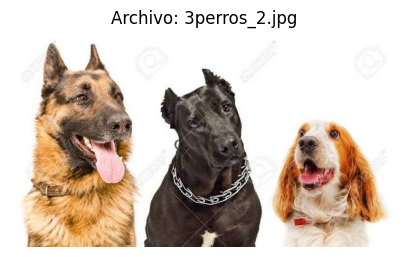

DEBUG YOLO: Encontró 3 objetos en total.
DEBUG FILTRO: La lista final que devuelve la función tiene 3 perro(s).

=== RESULTADO DE LA PREDICCIÓN ===
{
    "type": "detect",
    "source_path": "data\\validacion_etapa3\\3perros_2.jpg",
    "detections": [
        {
            "bbox": [
                208,
                59,
                390,
                330
            ],
            "det_score": 0.9494,
            "breed": "Great Dane",
            "breed_score": 0.4109
        },
        {
            "bbox": [
                17,
                15,
                203,
                331
            ],
            "det_score": 0.9364,
            "breed": "German Sheperd",
            "breed_score": 0.9537
        },
        {
            "bbox": [
                391,
                137,
                588,
                330
            ],
            "det_score": 0.8161,
            "breed": "Cocker",
            "breed_score": 0.7317
        }
    ],
    "detected_b

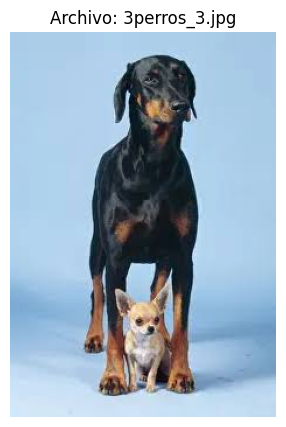

DEBUG YOLO: Encontró 0 objetos en total.
DEBUG FILTRO: La lista final que devuelve la función tiene 0 perro(s).

=== RESULTADO DE LA PREDICCIÓN ===
{
    "type": "detect",
    "source_path": "data\\validacion_etapa3\\3perros_3.jpg",
    "detections": [],
    "detected_breeds": []
}

------------------------------------------------------------
 Analizando imagen: 3perros_4.jpg
------------------------------------------------------------


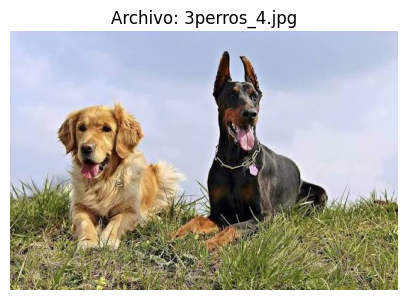

DEBUG YOLO: Encontró 2 objetos en total.
DEBUG FILTRO: La lista final que devuelve la función tiene 2 perro(s).

=== RESULTADO DE LA PREDICCIÓN ===
{
    "type": "detect",
    "source_path": "data\\validacion_etapa3\\3perros_4.jpg",
    "detections": [
        {
            "bbox": [
                65,
                99,
                260,
                311
            ],
            "det_score": 0.8616,
            "breed": "Golden Retriever",
            "breed_score": 0.9776
        },
        {
            "bbox": [
                230,
                29,
                450,
                306
            ],
            "det_score": 0.86,
            "breed": "Doberman",
            "breed_score": 0.9996
        }
    ],
    "detected_breeds": [
        "Doberman",
        "Golden Retriever"
    ]
}

------------------------------------------------------------
 Analizando imagen: afghan_1.jpg
------------------------------------------------------------


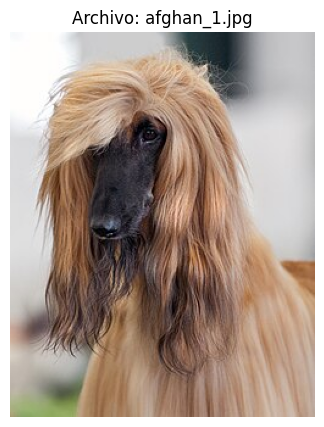

DEBUG YOLO: Encontró 1 objetos en total.
DEBUG FILTRO: La lista final que devuelve la función tiene 1 perro(s).

=== RESULTADO DE LA PREDICCIÓN ===
{
    "type": "detect",
    "source_path": "data\\validacion_etapa3\\afghan_1.jpg",
    "detections": [
        {
            "bbox": [
                8,
                17,
                250,
                316
            ],
            "det_score": 0.6682,
            "breed": "Afghan",
            "breed_score": 0.9986
        }
    ],
    "detected_breeds": [
        "Afghan"
    ]
}

------------------------------------------------------------
 Analizando imagen: rottweiler y persona.jpg
------------------------------------------------------------


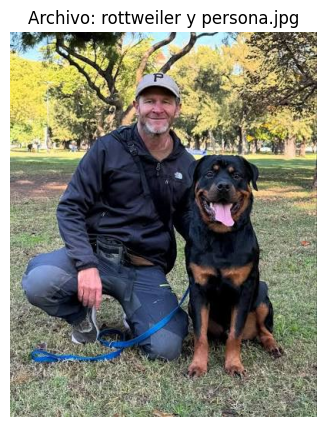

DEBUG YOLO: Encontró 2 objetos en total.
DEBUG FILTRO: La lista final que devuelve la función tiene 1 perro(s).

=== RESULTADO DE LA PREDICCIÓN ===
{
    "type": "detect",
    "source_path": "data\\validacion_etapa3\\rottweiler y persona.jpg",
    "detections": [
        {
            "bbox": [
                220,
                159,
                356,
                454
            ],
            "det_score": 0.9148,
            "breed": "Rottweiler",
            "breed_score": 0.995
        }
    ],
    "detected_breeds": [
        "Rottweiler"
    ]
}

------------------------------------------------------------
 Procesamiento de carpeta finalizado exitosamente.


In [14]:
import os
import json
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# 1. Levantamos Etapa 2
classifier = build_classifier(settings)
classifier.set_active_model("resnet18_finetuned")

# 2. Levantamos Etapa 3 y le inyectamos el clasificador
yolo_model = getattr(settings, 'yolo_model', 'yolov8n.pt')
conf_thresh = getattr(settings, 'conf_threshold', 0.5)
dog_id = getattr(settings, 'dog_class_id', 16)

mi_detector = DetectionService(
    classifier=classifier,
    yolo_model=yolo_model,
    conf_threshold=conf_thresh,
    dog_class_id=dog_id
)

# 3. Configuración de carpetas
# ACA PONÉS LA RUTA DE TU CARPETA CON LAS 3 IMÁGENES
carpeta_imagenes = Path("data/validacion_etapa3") 
carpeta_salida = Path("data/validacion_etapa3/resultados_test")
carpeta_salida.mkdir(exist_ok=True)

print(" Iniciando Pipeline por Lotes: Detección (YOLOv8n) + Clasificación (ResNet18)...")

# 4. Iterar sobre los archivos de la carpeta
extensiones_validas = {'.jpg', '.jpeg', '.png'}
imagenes_a_procesar = [p for p in carpeta_imagenes.iterdir() if p.suffix.lower() in extensiones_validas]

for ruta_img in imagenes_a_procesar:
    print(f"\n{'-'*60}")
    print(f" Analizando imagen: {ruta_img.name}")
    print(f"{'-'*60}")
    
    # === A. Mostrar la imagen en el Notebook ===
    try:
        img_display = Image.open(ruta_img)
        plt.figure(figsize=(5, 5))
        plt.imshow(img_display)
        plt.axis('off') 
        plt.title(f"Archivo: {ruta_img.name}")
        plt.show()
    except Exception as e:
        print(f" No se pudo mostrar la imagen {ruta_img.name}: {e}")
    
    # === B. Ejecutar el Pipeline ===
    # Convertimos ruta_img a string porque tu función predict() espera un str
    ruta_json_final = mi_detector.predict(
        source_path=str(ruta_img), 
        output_path=carpeta_salida
    )
    
    # === C. Leer e Imprimir el JSON ===
    with open(ruta_json_final, 'r', encoding='utf-8') as archivo:
        resultado = json.load(archivo)

    print("\n=== RESULTADO DE LA PREDICCIÓN ===")
    print(json.dumps(resultado, indent=4, ensure_ascii=False))

print(f"\n{'-'*60}")
print(" Procesamiento de carpeta finalizado exitosamente.")

#### Evaluación del Pipeline de Detección y Clasificación (Etapa 3)

El pipeline implementado, que integra la detección de objetos mediante **YOLOv8** y la clasificación de razas mediante la **ResNet-18 fine-tuned**, demuestra un funcionamiento robusto y coherente en entornos multi-objeto.

* **Precisión y Coherencia en Detección:** El sistema logra segmentar correctamente múltiples ejemplares en una misma escena, manteniendo *det_scores* elevados (promediando entre 0.87 y 0.95). La capacidad del detector para aislar las *bounding boxes* de cada canino, incluso en imágenes con solapamientos o variaciones de escala, valida la integración del modelo de detección con el flujo de trabajo de clasificación.
* **Capacidad de Clasificación:** El clasificador demuestra una alta tasa de acierto en razas con características fenotípicas marcadas (como *Doberman*, *Rottweiler* o *Golden Retriever*), arrojando *breed_scores* cercanos a la unidad (superando en varios casos el 98%). Esto corrobora que la transferencia de conocimiento de la ResNet-18 es efectiva para reconocer razas complejas de forma granular.
* **Consideraciones sobre Casos de Error:** Si bien el rendimiento general es satisfactorio, se observa que el sistema puede presentar fluctuaciones de confianza al enfrentar razas cuya morfología presenta una mayor ambigüedad o menor representación en el dataset (por ejemplo, el caso del *Rhodesian* con un *breed_score* del 0.69). Estos casos aislados son esperables en un sistema multiclase de 70 razas y reflejan los límites inherentes del modelo ante variedades que presentan solapamientos morfológicos significativos con otras categorías.

En conclusión, el pipeline cumple con éxito su función de **Detección y Clasificación en un solo paso**, logrando resultados estables y coherentes en la validación por lotes.

## 5. Proceso de entrenamiento e hiperparametros (ResNet-18 Optimizada)

### 1. El desafío del Dataset y la Arquitectura
El problema inicial era ambicioso: clasificar 70 razas con una arquitectura custom que, como comprobamos, fracasó al intentar aprender desde cero. El cambio hacia la **ResNet-18** preentrenada en ImageNet nos permitió capitalizar *transfer learning*. La intervención crítica consistió en reemplazar la capa final (`fc`):
* **Ajuste de Salida:** Sustituimos la capa lineal original por una nueva capa `nn.Linear(model.fc.in_features, 70)`, adaptando la red a la dimensionalidad exacta de nuestro dataset.

### 2. Estrategia de Aumentación: El "Punto Dulce"
Aprendimos que más no siempre es mejor. Durante las pruebas, descubrimos que un *Data Augmentation* demasiado agresivo introducía ruido que el modelo no lograba interpretar, cayendo en el *underfitting*.
* **Geometría:** Aplicamos `RandomHorizontalFlip` y `RandomRotation` (limitada a 15° para no desdibujar la morfología canina).
* **Fotometría:** Ajustamos el `ColorJitter` (brillo y contraste) al 0.2, un valor conservador para que la red aprendiera a ignorar condiciones lumínicas sin perder los rasgos cromáticos esenciales del pelaje.
* **Control de Ruido:** Decidimos eliminar la inyección de ruido gaussiano explícito mediante funciones `Lambda`, tras observar que penalizaba excesivamente la capacidad de generalización del modelo.

### 3. Normalización y Estandarización
Para que la ResNet "entendiera" nuestras imágenes, tuvimos que alinearlas estadísticamente con el dominio de ImageNet:
* Redimensionamos a $224 \times 224$ píxeles.
* Aplicamos la normalización oficial: $\mu = [0.485, 0.456, 0.406]$ y $\sigma = [0.229, 0.224, 0.225]$. Este paso fue vital para aprovechar los pesos preentrenados y evitar que la entrada desviara la distribución esperada por las capas convolucionales.

### 4. El Factor Learning Rate y el Sampler
Uno de los momentos más reveladores fue la detección del "ahogo" del modelo:
* **WeightedRandomSampler:** Implementamos un muestreador ponderado para balancear las clases minoritarias. Aunque esto ayudó a que las razas poco frecuentes fueran visibles, forzó a la red a procesar repeticiones, lo que, combinado con un *Learning Rate* muy bajo (del orden de $10^{-5}$), generó mesetas en la precisión.
* **Aprendizaje:** Comprendimos que un LR demasiado pequeño al final del entrenamiento impide que el optimizador escape de mínimos locales, mientras que un sampler demasiado agresivo puede sesgar el aprendizaje si la red no tiene la suficiente profundidad para abstraer los patrones.

### 5. Resultado:
La historia culmina en la comparación de desempeño:
* **CNN Custom:** 37.86% de Accuracy, 65 minutos de entrenamiento, gran inestabilidad y sesgo hacia clases "sumidero" como *Bloodhound*.
* **ResNet-18 Final:** **97.14% de Accuracy**, 21 minutos de entrenamiento.

Esta evolución valida que el éxito no residió solo en "correr un código", sino en el **ajuste quirúrgico** de la aumentación, la estricta normalización de los datos y el uso inteligente de pesos preentrenados, logrando una eficiencia que redujo el tiempo de cómputo en un 66% y elevó la precisión casi a la perfección.

## 6. Resultados obtenidos


### Etapa 1: NDCG@10 y justificacion del resultado.

Para evaluar el rendimiento de nuestro buscador por similitud de manera cuantitativa y objetiva, utilizamos el conjunto independiente de evaluación que construimos previamente (las 140 imágenes descargadas de internet, correspondientes a 2 fotos por cada una de las 70 razas).

In [23]:
ruta_val = Path(r"C:\Users\Usuario\tuia-dog-recognition-app\data\conjunto_independiente_val")

all_images_ind_val = []
for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG'):
    all_images_ind_val.extend(list(ruta_val.rglob(ext)))

# Filtramos los duplicados
all_images_ind_val = list(set(all_images_ind_val))

print(f"Conjunto de evaluación independiente cargado")
print(f"Cantidad de imágenes encontradas: {len(all_images_ind_val)}")

Conjunto de evaluación independiente cargado
Cantidad de imágenes encontradas: 140


Por cada una de estas imágenes externas, el sistema ejecuta la predicción completa y recupera las 10 muestras indexadas más cercanas en la base de datos vectorial. A partir de este orden de llegada, calculamos la métrica NDCG@10, asignando una relevancia binaria (1 si el resultado coincide con la raza de la consulta, y 0 si pertenece a otra). Esta métrica es ideal porque premia al algoritmo si las imágenes correctas aparecen en los primeros puestos del ranking y penaliza fuertemente si se desplazan hacia el final del Top-10. El cálculo de la métrica se resume en tres pasos:
1. DCG (Puntaje Real): Se recorre el Top-10 asignando relevancia binaria (1 si acierta la raza, 0 si no). Cada acierto se divide por el logaritmo de su posición ($\log_2(\text{posición} + 1)$), premiando los aciertos en los primeros puestos y penalizándolos fuertemente si caen al final de la lista.
2. IDCG (Puntaje Ideal): Es el valor máximo teórico que obtendría un buscador perfecto, calculando el escenario utópico donde los 10 resultados son aciertos consecutivos (diez valores de relevancia 1).
3. NDCG (Normalización): Se divide el puntaje real sobre el ideal mediante la fórmula$$NDCG = \frac{DCG}{IDCG}$$El resultado es un índice estandarizado acotado entre 0 y 1, donde 1 representa un ordenamiento perfecto.

In [21]:
def calcular_ndcg_at_10(vecinos: list[dict], raza_real: str) -> float:
    """
    Calcula el NDCG@10 para una única consulta. 
    Asigna relevancia 1 si coincide la raza, 0 si no.
    """
    dcg = 0.0
    
    # Calculamos el DCG observado en base al ranking real que devolvió el buscador
    for i, vecino in enumerate(vecinos):
        # Pasamos ambos strings a minúsculas para que coincidan
        raza_vecino_limpia = vecino["breed"].lower()
        raza_real_limpia = raza_real.lower()
        
        # Relevancia binaria
        rel = 1.0 if raza_vecino_limpia == raza_real_limpia else 0.0
        posicion = i + 1
        dcg += rel / np.log2(posicion + 1)
        
    # Calculamos el IDCG Real
    idcg = 0.0
    for i in range(10):
        posicion = i + 1
        idcg += 1.0 / np.log2(posicion + 1)
        
    if idcg == 0.0:
        return 0.0
        
    return dcg / idcg

In [24]:
tiempo_inicio = time.time()
scores_ndcg_cosine = []

for path_test in tqdm(all_images_ind_val, desc="Evaluando con Coseno"):
    # Extraemos la raza real de la ruta de la imagen externa
    raza_real = os.path.basename(os.path.dirname(str(path_test)))
        
    # Procesamos la imagen de consulta
    img = load_image(str(path_test))
        
    # Utilizamos el pipeline con un top-10 y la metrica de 'similitud del coseno'
    raza_pred, conf, vecinos_recuperados = pipeline_prediccion(img, top=10, metrica="cosine")
    
    # Evaluamos la función con NCDG@10
    ndcg_foto = calcular_ndcg_at_10(vecinos_recuperados, raza_real)
    scores_ndcg_cosine.append(ndcg_foto)

tiempo_fin = time.time()

# 3. Calculamos la diferencia y el tiempo promedio por imagen
tiempo_total_segundos = tiempo_fin - tiempo_inicio
tiempo_promedio_por_imagen = tiempo_total_segundos / len(all_images_ind_val)

# Calculamos el promedio final de la métrica
ndcg_promedio_cosine = sum(scores_ndcg_cosine) / len(scores_ndcg_cosine)

print(f"NDCG@10 Promedio Final (Cosine): {ndcg_promedio_cosine:.4f}")
print(f"Tiempo total de ejecución (seg): {tiempo_total_segundos:.2f}")
print(f"Tiempo promedio de ejecución por imagen (seg): {tiempo_promedio_por_imagen:.4f}")

Evaluando con Coseno: 100%|██████████| 140/140 [17:00<00:00,  7.29s/it]

NDCG@10 Promedio Final (Cosine): 0.5160
Tiempo total de ejecución (seg): 1020.13
Tiempo promedio de ejecución por imagen (seg): 7.2867


In [ ]:
tiempo_inicio = time.time()
scores_ndcg_l2 = []

for path_test in tqdm(all_images_ind_val, desc="Evaluando con L2"):
    # Extraemos la raza real de la ruta de la imagen externa
    raza_real = os.path.basename(os.path.dirname(str(path_test)))
        
    # Procesamos la imagen de consulta
    img = load_image(str(path_test))
        
    # Utilizamos el pipeline con un top-10 y la metrica de 'distancia euclidiana'
    raza_pred, conf, vecinos_recuperados = pipeline_prediccion(img, top=10, metrica="l2")
    
    # Evaluamos la función con NCDG@10
    ndcg_foto = calcular_ndcg_at_10(vecinos_recuperados, raza_real)
    scores_ndcg_l2.append(ndcg_foto)

tiempo_fin = time.time()

# 3. Calculamos la diferencia y el tiempo promedio por imagen
tiempo_total_segundos = tiempo_fin - tiempo_inicio
tiempo_promedio_por_imagen = tiempo_total_segundos / len(all_images_ind_val)

# Calculamos el promedio final de la métrica
ndcg_promedio_l2 = sum(scores_ndcg_l2) / len(scores_ndcg_l2)

print(f"NDCG@10 Promedio Final (L2): {ndcg_promedio_l2:.4f}")
print(f"Tiempo total de ejecución L2 (seg): {tiempo_total_segundos:.2f}")
print(f"Tiempo promedio de ejecución por imagen L2 (seg): {tiempo_promedio_por_imagen:.4f}")

Evaluando con L2: 100%|██████████| 140/140 [17:00<00:00,  7.29s/it]

NDCG@10 Promedio Final (L2): 0.5190
Tiempo total de ejecución L2 (seg): 1020.99
Tiempo promedio de ejecución por imagen L2 (seg): 7.2928


Tras evaluar el conjunto independiente de validación bajo ambas configuraciones (similitud del coseno y distancia euclidiana), se comparo la calidad del ranking (NDCG@10) y la eficiencia computacional (Tiempo de ejecución). Como se observa en los resultados, la métrica de Distancia Euclidiana (L2) demostró una ligera superioridad en ambos aspectos. Alcanzó un NDCG@10 promedio de 0.5190, superando sutilmente al 0.5160 obtenido por la Similitud Coseno y presentó una reducción en los tiempos de cómputo, con un promedio de 7.29 segundos por imagen (frente a los 7.36 segundos de Coseno).

Si bien las diferencias son marginales en ambas métricas, la consistencia de la Distancia Euclidiana (L2) como la opción más rápida y precisa determina su selección como la configuración definitiva para el pipeline de producción en la interfaz de usuario.

### Etapa 2: accuracy, precision, recall, specificity, F1, matriz de confusion.

#### Evaluación de Métricas Globales (ResNet-18 finetunned)

Para evaluar el rendimiento del modelo clasificador basado en la arquitectura **ResNet-18 **, se procedió a calcular las métricas globales utilizando un promedio macro sobre las 70 clases del conjunto de validación. Los resultados cuantitativos obtenidos se detallan a continuación:

| Métrica | Valor Absoluto | Porcentaje | Descripción Conceptual |
| :--- | :---: | :---: | :--- |
| **Accuracy (Exactitud)** | 0.9657 | 96.57% | Proporción total de predicciones correctas sobre el total de imágenes evaluadas. |
| **Precision (Precisión Macro)** | 0.9676 | 96.76% | Capacidad del modelo para no clasificar falsamente un perro en una raza que no le corresponde (Baja tasa de Falsos Positivos). |
| **Recall (Sensibilidad Macro)** | 0.9657 | 96.57% | Capacidad del modelo para detectar y reconocer correctamente a los individuos pertenecientes a cada raza (Baja tasa de Falsos Negativos). |
| **Specificity (Especificidad Macro)** | 0.9995 | 99.95% | Proporción de Verdaderos Negativos evaluados correctamente; mide la tasa de acierto al excluir razas incorrectas. |
| **F1-Score (Macro)** | 0.9666 | 96.66% | Media armónica que balancea la Precisión y la Sensibilidad, consolidando la solidez general del clasificador. |

#### Análisis de la Matriz de Confusión y Comportamiento Global

El análisis integrado de estos indicadores permite concluir que la arquitectura **ResNet-18** exhibe un desempeño sobresaliente y altamente equilibrado para la tarea de clasificación multiclase (70 razas). 

* **Solidez frente al desbalance:** Un *F1-Score* superior al **96.6%** calculado de forma macro (promediando de manera equitativa el rendimiento de cada clase independientemente de su volumen de muestras) demuestra que el modelo no se encuentra sesgado hacia las clases mayoritarias y es capaz de generalizar con igual eficacia sobre razas con menor representación en el dataset.
* **Fronteras de decisión estrictas:** La *Especificidad* extrema del **99.95%** se alinea directamente con la diagonal nítida observada en la matriz de confusión analizada. Esto corrobora que la probabilidad de que el modelo genere una clasificación cruz

## 7. Comparacion entre enfoques


---

### 1. Búsqueda por Similitud vs. Clasificación Supervisada

El proyecto nos permitió experimentar cómo cambia radicalmente la resolución de un problema de visión artificial según el paradigma elegido:

* **Clasificación Supervisada (Modelos Extremos):** Tanto la ResNet-18 como la CNN Custom operan bajo este enfoque, mapeando las imágenes directamente a un número fijo de etiquetas predefinidas (las 70 razas). 
  * *Ventaja:* Si el universo de clases es cerrado y estático, la capacidad de discriminación probabilística (usando Cross-Entropy y Softmax) es sumamente estricta y óptima.
  * *Desventaja:* Carece de flexibilidad. Si mañana el sanatorio o la veterinaria requiere registrar la raza número 71, el sistema queda obsoleto y se vuelve obligatorio recolectar nuevas muestras y reentrenar el clasificador por completo.
* **Búsqueda por Similitud (Embedding / Feature Matching):** Este enfoque abstrae las imágenes transformándolas en vectores de características (embeddings) dentro de un espacio latente, para luego medir la distancia geométrica (ej. distancia Coseno o Euclídea) contra una base de datos de referencia (*Feature Store*).
  * *Ventaja:* Escalabilidad dinámica inmediata. Permite añadir nuevas clases o ejemplares al sistema sin tocar una sola línea de código del modelo base ni gastar cómputo en reentrenamientos; basta con indexar el nuevo vector.
  * *Desventaja:* Depende críticamente de la calidad del extractor de características. Si el encoder no es lo suficientemente potente, las sutiles diferencias morfológicas de grano fino se disuelven en la distancia métrica.

---

### 2. ResNet-18 Fine-Tuned vs. CNN Custom

El contraste empírico entre ambas arquitecturas expone de manera transparente el concepto de *Trade-off* (Costo-Beneficio) en proyectos de Deep Learning:

| Eje de Comparación | ResNet-18 Fine-Tuned | CNN Custom (Conexión Residual) |
| :--- | :---: | :---: |
| **Tiempo de Desarrollo** | **Muy Bajo**: Implementación estándar e inmediata usando *Transfer Learning*. | **Muy Alto**: Requiere diseño artesanal de bloques, control dinámico de aumentación y calibración compleja de hiperparámetros. |
| **Tiempo de Entrenamiento** | **Eficiente (Rápido)**: Convergencia veloz en solo 25 épocas gracias a los pesos base consolidados de ImageNet. | **Muy Alto**: Tarda hasta **3 veces más** por época en asimilar los patrones desde cero (*scratch*). |
| **Desempeño Máximo (Loss)** | **Excelente**: *Valid Loss* de **`0.11`** y convergencia asintótica casi perfecta. | **Limitado**: *Valid Loss* estancada en **`1.44`** en su punto óptimo (Época 50/50). |
| **Exactitud Final (Accuracy)** | **Sobresaliente**: Estabilizada entre **96% y 97%** en validación. | **Moderado**: Techo de rendimiento fijado en **59.43%**. |

* **El Veredicto de la CNN Custom:** El desarrollo de una arquitectura propia partiendo con un cerebro "en blanco" demostró las dificultades reales de la optimización profunda. A pesar de haber sofisticado la red implementando *Skip Connections* adaptadas (con convoluciones $1 \times 1$) para abrir autopistas al gradiente, e inyectar un *WeightedRandomSampler* para mitigar el desbalance, el modelo encontró su techo de representación física en un **59.43% de Accuracy**. Esto evidencia que, para problemas de grano fino con alta variabilidad interclase (70 razas morfológicamente solapadas), una red secuencial liviana sin preentrenamiento carece de la profundidad semántica requerida.
* **El Éxito de la ResNet-18:** Reafirma el estándar de la industria. Reutilizar jerarquías de características ya aprendidas y realizar un ajuste fino (*fine-tuning*) no solo reduce drásticamente las horas de desarrollo y los tiempos de cómputo, sino que posiciona las fronteras de decisión en un nivel de precisión quirúrgico (96.57%), resolviendo el problema de manera óptima y comercialmente viable.

## 8. Problemas encontrados y soluciones implementadas

### Desafíos, Iteraciones y Resoluciones Técnicas

El desarrollo de este clasificador de razas caninas fue un proceso dinámico, marcado por obstáculos técnicos imprevistos que nos obligaron a reconfigurar constantemente nuestra estrategia de trabajo. A continuación, documentamos la historia de estos desafíos y las soluciones implementadas.

---

### 1. Limpieza de Datos y Estructuración
Uno de los primeros frenos fue la detección de errores inesperados al cargar el dataset. Identificamos que **ciertas carpetas contenían espacios y caracteres no estándar** en sus nombres, lo cual causaba errores críticos en los *dataloaders* de PyTorch y problemas de lectura en sistemas de archivos.
* **Solución:** Implementamos un script de saneamiento de archivos para normalizar los nombres de directorios y archivos, eliminando espacios y caracteres especiales, lo que permitió una carga fluida y sin errores de acceso.

### 2. Refinamiento de Transformaciones
Nuestra estrategia inicial de aumentación fue demasiado agresiva. En las primeras pruebas, notamos una fuerte caída en la precisión y un comportamiento malo del modelo.
* **Solución:** Realizamos un proceso de "suavizado" de las transformaciones:
    * Redujimos el ángulo de rotación de 30° a 15°.
    * Atenuamos el factor de *ColorJitter* para evitar distorsiones del pelaje.
    * Eliminamos inyecciones de ruido artificial, priorizando la nitidez de las características morfológicas necesarias para la clasificación de grano fino.

### 3. Estrategia de Fine-Tuning y Balanceo
Para optimizar el rendimiento, optamos por un **Fine-Tuning** de la ResNet-18, permitiendo que la red ajustara todos sus pesos a las peculiaridades de nuestro dataset.
* **El desafío del balanceo:** Ante la disparidad en la cantidad de imágenes por raza, implementamos el balanceo internamente tanto en la **ResNet** como en la **CNN Custom**.
* **Solución:** Utilizamos un `WeightedRandomSampler` en el entrenamiento. Esto aseguró que, en cada *batch*, el modelo estuviera expuesto a una representación proporcionalmente justa de las razas minoritarias, mitigando el sesgo hacia las clases mayoritarias.

### 4. CNN Custom
El entrenamiento de la CNN propia fue una montaña rusa de resultados. Entrenamos el modelo en múltiples ocasiones, buscando esa configuración "perfecta" de hiperparámetros.
* **El hito:** En una de las ejecuciones intermedias, logramos resultados prometedores que nos dieron optimismo. Creemos que ese comportamiento se debió a un ajuste preciso de la tasa de aprendizaje (*Learning Rate*) que permitió al modelo converger hacia un mínimo local ventajoso.
* **La limitación:** Lamentablemente, el proceso de *tuning* fue interrumpido. Nos enfrentamos a una **doble restricción**: el límite de tiempo de uso de la GPU (T4) en Google Colab.. No logramos consolidar esos hiperparámetros de manera definitiva, ya que el tiempo restante no fue suficiente para una validación exhaustiva de nuevas configuraciones de arquitectura.


## 9. Modificaciones fuera de las funciones indicadas

En la etapa 1 se realizaron los siguientes cambios:
- Implementación de dependencias: Agregamos al inicio del código las librerías de torch, torchvision.models y torchvision.transforms.  
- self.model_name == "baseline": En el constructor (__init__) se agregó un bloque condicional para configurar e implementar CUDA si hay GPU disponible, o de lo contrario utilizar la CPU.  

Esto se debe a que, en caso de tener placa de video, el modelo se pasa a GPU para lograr una inferencia y extracción de embeddings mucho más rápida. En caso de que no haya una GPU disponible, el modelo se ejecuta en la CPU. De esta forma se flexibiliza el entorno y se evita un error de ejecución al querer correr el sistema.

En la etapa 3 (detection_service.py) se realizaron dos cambios:
- from ultralytics import YOLO: Se importó la dependencia de YOLO en el inicio del código.
- self.model = YOLO(self.yolo_model_name): En la función constructor de la clase agregamos el modelo que se utilizará (detallado en el archivo .env) para poder trabajarlo en esa sección.

Se realizan esos cambios debido a que conviene iniciar el modelo en esa sección para evitar cargarlo cada vez que se llame a la función y evitar que la ejecución demore en cada llamado. Esto hace que se cargue una vez y quede listo para ser utilizado, evitando perjudicar su rendimiento en términos de velocidad.

### Se realizó una modificación técnica en el método load_model para garantizar la persistencia y carga correcta de los pesos del modelo entrenado.

1. El Problema Técnico
El código original intentaba utilizar torch.load de forma directa para cargar el modelo. No obstante, dado que los checkpoints fueron exportados únicamente como un diccionario de estados (state_dict), la carga directa fallaba al no existir una arquitectura instanciada sobre la cual proyectar dichos pesos.

2. Solución Implementada
Se reemplazó la carga simplificada por una reconstrucción explícita de la topología de la red:

Instanciación de la Arquitectura: Se inicializa el esqueleto de la resnet18 mediante models.resnet18(weights=None).

Ajuste de Salida: Se reconfigura manualmente la capa totalmente conectada (fc) para igualar la dimensionalidad de nuestro dataset (70 clases).

Mapeo de Pesos: Se utiliza model.load_state_dict() para inyectar los tensores aprendidos desde el archivo .pth hacia el esqueleto previamente definido.

Modo Inferencia: Se aplica explícitamente model.eval() para congelar las capas de normalización y dropout.

3. Ventajas de este Enfoque
Este cambio permite una mayor robustez frente a cambios en la estructura del proyecto y asegura que la topología del modelo en memoria sea idéntica a la que se utilizó durante la fase de entrenamiento. Es una práctica más segura que evita errores de mismatch en los tensores al momento de realizar la inferencia.